In [ ]:
!pip install mediapipe xgboost lightgbm

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Update this path to your exact ICCA folder location
BASE_DIR = '/content/drive/MyDrive/ICCA'
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset mapping based on your directory structure
FOLDER_PATHS = {
    'Frustrated':   f'{BASE_DIR}/Engaged/Frustrated',
    'Focused':      f'{BASE_DIR}/Engaged/Focused',
    'Confused':     f'{BASE_DIR}/Engaged/Confused',
    'Looking Away': f'{BASE_DIR}/Not Engaged/Looking Away',
    'Drowsy':       f'{BASE_DIR}/Not Engaged/Drowsy',
    'Bored':        f'{BASE_DIR}/Not Engaged/Bored',
    'attentive':    f'{BASE_DIR}/attentive',
    'inattentive':  f'{BASE_DIR}/inattentive'
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mediapipe xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn joblib opencv-python-headless -q

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Libraries installed and loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries installed and loaded.


In [ ]:
ICCA_DIR = '/content/drive/MyDrive/ICCA'
OUTPUT_DIR = f'{ICCA_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Map folder names to class labels
CLASS_MAP = {
    'Frustrated': 'frustrated',
    'Focused': 'focused',
    'Confused': 'confused',
    'Looking Away': 'looking_away',
    'Drowsy': 'drowsy',
    'Bored': 'bored',
    'attentive': 'attentive',
    'inattentive': 'inattentive'
}

# Folder paths (as per your structure)
FOLDER_PATHS = {
    'Frustrated': f'{ICCA_DIR}/Engaged/Frustrated',
    'Focused': f'{ICCA_DIR}/Engaged/Focused',
    'Confused': f'{ICCA_DIR}/Engaged/Confused',
    'Looking Away': f'{ICCA_DIR}/Not Engaged/Looking Away',
    'Drowsy': f'{ICCA_DIR}/Not Engaged/Drowsy',
    'Bored': f'{ICCA_DIR}/Not Engaged/Bored',
    'attentive': f'{ICCA_DIR}/attentive',
    'inattentive': f'{ICCA_DIR}/inattentive'
}

print("Checking dataset folders:")
for name, path in FOLDER_PATHS.items():
    if os.path.exists(path):
        n_images = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {name:15s} -> {n_images} images")
    else:
        print(f"  {name:15s} -> NOT FOUND")

Checking dataset folders:
  Frustrated      -> 360 images
  Focused         -> 347 images
  Confused        -> 369 images
  Looking Away    -> 423 images
  Drowsy          -> 263 images
  Bored           -> 358 images
  attentive       -> 404 images
  inattentive     -> 433 images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries installed and loaded.
Checking dataset folders:
  Frustrated      -> 360 images
  Focused         -> 347 images
  Confused        -> 369 images
  Looking Away    -> 423 images
  Drowsy          -> 263 images
  Bored           -> 358 images
  attentive       -> 404 images
  inattentive     -> 433 images
Loaded existing features from /content/drive/MyDrive/ICCA/outputs/features_8class.csv, shape: (2667, 13)
Classes: ['attentive', 'bored', 'confused', 'drowsy', 'focused', 'frustrated', 'inattentive', 'looking_away']
Class distribution:
 label
confused        369
looking_away    364
bored           351
focused         347
frustrated      344
attentive       330
inattentive     329
drowsy          233
Name: count, dtype: int64
Train size: 2133, Test size: 534

SVM (RBF kernel)
Test Accuracy: 94.38%
5‑Fold CV: 93.30% ± 0.35%
Macro F1: 94.04%

Classificati

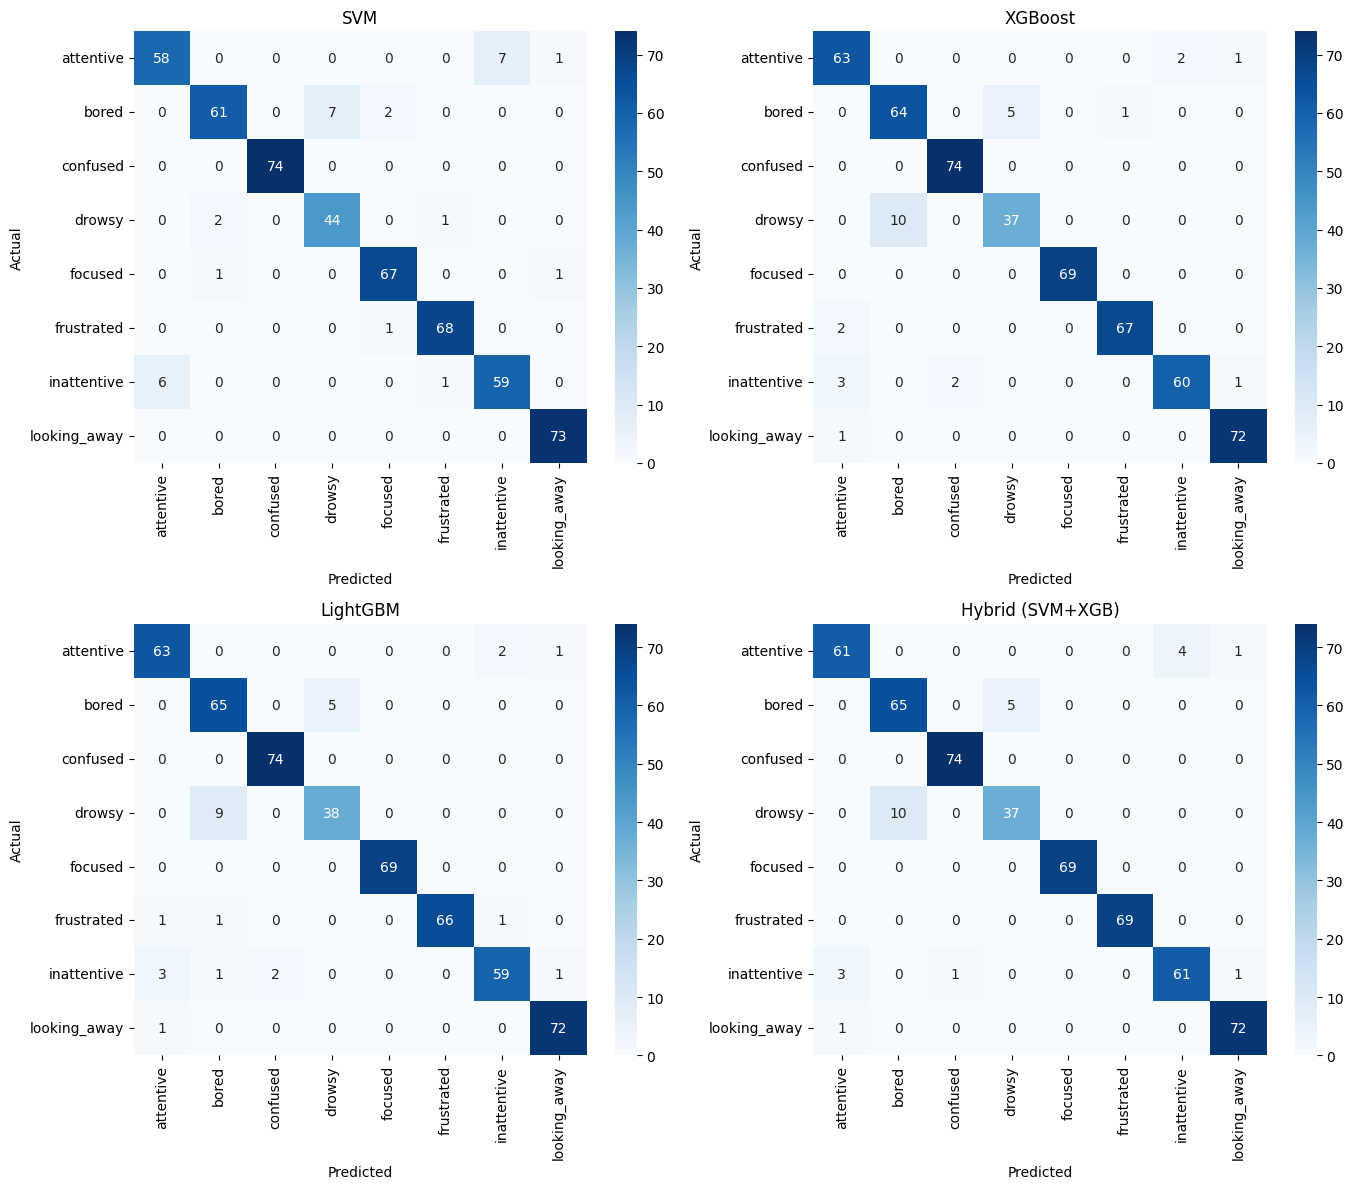

In [ ]:
!pip install mediapipe xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn joblib opencv-python-headless -q

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Libraries installed and loaded.")

# ============================================================
# Cell 2: Define paths and class mapping
# ============================================================
ICCA_DIR = '/content/drive/MyDrive/ICCA'
OUTPUT_DIR = f'{ICCA_DIR}/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Map folder names to class labels
CLASS_MAP = {
    'Frustrated': 'frustrated',
    'Focused': 'focused',
    'Confused': 'confused',
    'Looking Away': 'looking_away',
    'Drowsy': 'drowsy',
    'Bored': 'bored',
    'attentive': 'attentive',
    'inattentive': 'inattentive'
}

# Folder paths (as per your structure)
FOLDER_PATHS = {
    'Frustrated': f'{ICCA_DIR}/Engaged/Frustrated',
    'Focused': f'{ICCA_DIR}/Engaged/Focused',
    'Confused': f'{ICCA_DIR}/Engaged/Confused',
    'Looking Away': f'{ICCA_DIR}/Not Engaged/Looking Away',
    'Drowsy': f'{ICCA_DIR}/Not Engaged/Drowsy',
    'Bored': f'{ICCA_DIR}/Not Engaged/Bored',
    'attentive': f'{ICCA_DIR}/attentive',
    'inattentive': f'{ICCA_DIR}/inattentive'
}

print("Checking dataset folders:")
for name, path in FOLDER_PATHS.items():
    if os.path.exists(path):
        n_images = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {name:15s} -> {n_images} images")
    else:
        print(f"  {name:15s} -> NOT FOUND")

# ============================================================
# Cell 3: Feature extraction using MediaPipe Face Landmarker
# ============================================================
# Download the face landmarker model if not present
LANDMARK_MODEL_PATH = '/content/face_landmarker.task'
if not os.path.exists(LANDMARK_MODEL_PATH):
    !wget -q -O /content/face_landmarker.task \
        https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

# Initialize FaceLandmarker
landmarker = mp_vision.FaceLandmarker.create_from_options(
    mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=LANDMARK_MODEL_PATH),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5
    )
)

# Landmark indices
LEFT_EYE = [362,385,387,263,373,380]
RIGHT_EYE = [33,160,158,133,153,144]
LEFT_BROW = [276,283,282,295,285]
RIGHT_BROW = [46,53,52,65,55]
MOUTH_CORNERS = [61,291]
MOUTH_TOP, MOUTH_BOTTOM = 13, 14
NOSE_TIP, CHIN = 1, 152
LEFT_CHEEK, RIGHT_CHEEK = 234, 454

FEAT_COLS = ['nose_x','nose_y','chin_y','avg_ear','head_tilt',
             'left_ear','right_ear','eye_asym',
             'brow_raise','brow_asym','mouth_curve','face_ratio']

def ear(lm, idx):
    p = [(lm[i].x, lm[i].y) for i in idx]
    A = np.linalg.norm(np.array(p[1])-np.array(p[5]))
    B = np.linalg.norm(np.array(p[2])-np.array(p[4]))
    C = np.linalg.norm(np.array(p[0])-np.array(p[3])) + 1e-6
    return (A+B)/(2*C)

def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None
    lm = result.face_landmarks[0]
    le_v = ear(lm, LEFT_EYE)
    re_v = ear(lm, RIGHT_EYE)
    lb_h = lm[LEFT_BROW[2]].y - lm[LEFT_EYE[1]].y
    rb_h = lm[RIGHT_BROW[2]].y - lm[RIGHT_EYE[1]].y
    ml_y = lm[MOUTH_CORNERS[0]].y
    mr_y = lm[MOUTH_CORNERS[1]].y
    mc_y = (lm[MOUTH_TOP].y + lm[MOUTH_BOTTOM].y)/2
    fw = abs(lm[LEFT_CHEEK].x - lm[RIGHT_CHEEK].x)
    fh = abs(lm[NOSE_TIP].y - lm[CHIN].y) + 1e-6
    return [lm[NOSE_TIP].x, lm[NOSE_TIP].y, lm[CHIN].y,
            (le_v+re_v)/2, abs(lm[LEFT_EYE[0]].y - lm[RIGHT_EYE[0]].y),
            le_v, re_v, abs(le_v-re_v),
            -((lb_h+rb_h)/2), abs(lb_h-rb_h),
            mc_y - (ml_y+mr_y)/2, fw/fh]

# ============================================================
# Cell 4: Extract features from all images and create DataFrame
# ============================================================
CSV_PATH = f'{OUTPUT_DIR}/features_8class.csv'
if not os.path.exists(CSV_PATH):
    print("Extracting facial landmark features (this may take a few minutes)...")
    rows = []
    skipped = 0
    for folder_name, folder_path in FOLDER_PATHS.items():
        label = CLASS_MAP[folder_name]
        if not os.path.exists(folder_path):
            print(f"Skipping {folder_name} - path not found")
            continue
        imgs = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"Processing {folder_name} ({len(imgs)} images)...")
        for fname in imgs:
            feats = extract_features(os.path.join(folder_path, fname))
            if feats:
                rows.append(feats + [label])
            else:
                skipped += 1
    df_feat = pd.DataFrame(rows, columns=FEAT_COLS + ['label'])
    df_feat.to_csv(CSV_PATH, index=False)
    print(f"Saved features to {CSV_PATH}")
    print(f"Total samples: {len(df_feat)}, Skipped: {skipped}")
else:
    df_feat = pd.read_csv(CSV_PATH)
    print(f"Loaded existing features from {CSV_PATH}, shape: {df_feat.shape}")

# ============================================================
# Cell 5: Prepare data for training
# ============================================================
X = df_feat[FEAT_COLS].values
y = df_feat['label'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", list(le.classes_))
print("Class distribution:\n", df_feat['label'].value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Scale features for SVM (others can handle unscaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# Cell 6: Train SVM
# ============================================================
print("\n" + "="*60)
print("SVM (RBF kernel)")
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_cv = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Test Accuracy: {svm_acc*100:.2f}%")
print(f"5‑Fold CV: {svm_cv.mean()*100:.2f}% ± {svm_cv.std()*100:.2f}%")
print(f"Macro F1: {svm_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_, digits=3))

# ============================================================
# Cell 7: Train XGBoost
# ============================================================
print("\n" + "="*60)
print("XGBoost")
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                    subsample=0.85, colsample_bytree=0.85,
                    use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy')
print(f"Test Accuracy: {xgb_acc*100:.2f}%")
print(f"5‑Fold CV: {xgb_cv.mean()*100:.2f}% ± {xgb_cv.std()*100:.2f}%")
print(f"Macro F1: {xgb_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, digits=3))

# ============================================================
# Cell 8: Train LightGBM
# ============================================================
print("\n" + "="*60)
print("LightGBM")
lgbm = LGBMClassifier(n_estimators=400, num_leaves=63, learning_rate=0.06,
                      subsample=0.85, colsample_bytree=0.85,
                      min_child_samples=10, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm, average='macro')
lgbm_cv = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='accuracy')
print(f"Test Accuracy: {lgbm_acc*100:.2f}%")
print(f"5‑Fold CV: {lgbm_cv.mean()*100:.2f}% ± {lgbm_cv.std()*100:.2f}%")
print(f"Macro F1: {lgbm_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_, digits=3))

# ============================================================
# Cell 9: Hybrid (SVM + XGBoost) using probability averaging
# ============================================================
print("\n" + "="*60)
print("Hybrid (SVM + XGBoost) – soft voting")
# Get probabilities from SVM and XGBoost
prob_svm = svm.predict_proba(X_test_scaled)
prob_xgb = xgb.predict_proba(X_test)
hybrid_probs = (prob_svm + prob_xgb) / 2
y_pred_hybrid = np.argmax(hybrid_probs, axis=1)
hybrid_acc = accuracy_score(y_test, y_pred_hybrid)
hybrid_f1 = f1_score(y_test, y_pred_hybrid, average='macro')

print(f"Test Accuracy: {hybrid_acc*100:.2f}%")
print(f"Macro F1: {hybrid_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hybrid, target_names=le.classes_, digits=3))

# ============================================================
# Cell 10: Confusion Matrices
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
models = [('SVM', y_pred_svm), ('XGBoost', y_pred_xgb),
          ('LightGBM', y_pred_lgbm), ('Hybrid (SVM+XGB)', y_pred_hybrid)]
for ax, (name, pred) in zip(axes.flat, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 11: XGBoost Training vs Validation Curves
# ============================================================

from sklearn.metrics import log_loss, roc_auc_score
from sklearn.preprocessing import label_binarize

# Create validation split from training set
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

xgb_curve = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    objective='multi:softprob',
    eval_metric=['mlogloss', 'merror'],
    random_state=42,
    n_jobs=-1
)

eval_set = [
    (X_train_xgb, y_train_xgb),
    (X_val_xgb, y_val_xgb)
]

xgb_curve.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=eval_set,
    verbose=False
)

results = xgb_curve.evals_result()

print("XGBoost evaluation history collected.")

XGBoost evaluation history collected.


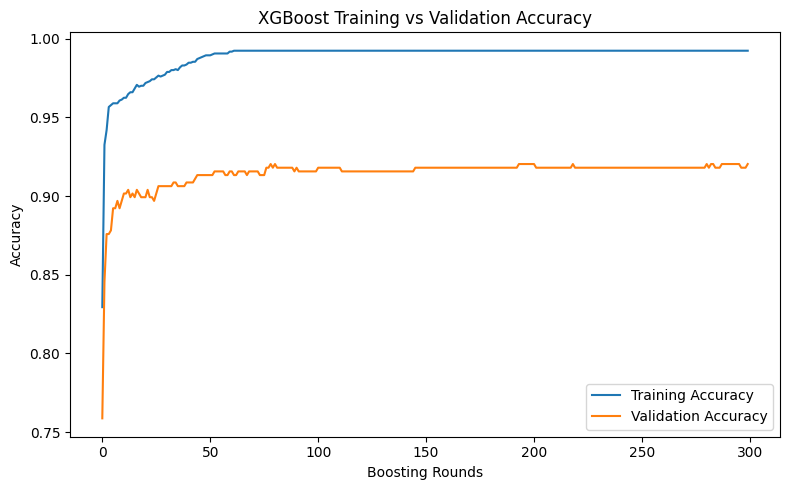

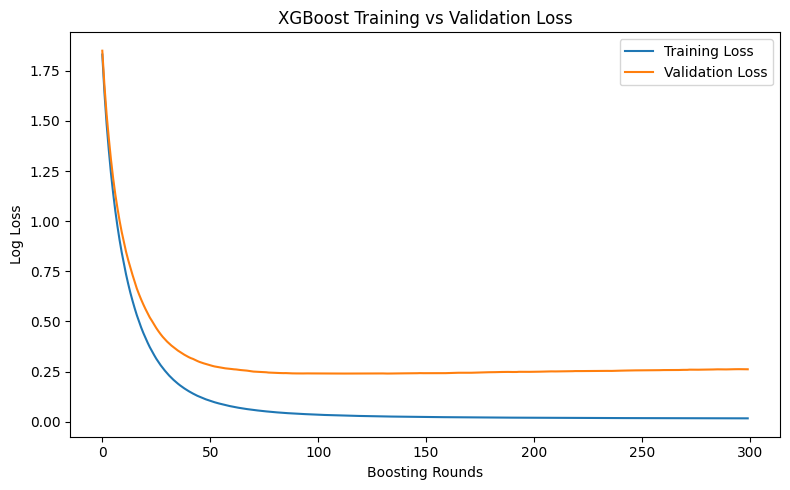

In [ ]:
# ============================================================
# Cell 12: Plot XGBoost Accuracy & Loss Curves
# ============================================================

train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']

train_error = results['validation_0']['merror']
val_error = results['validation_1']['merror']

train_acc = [1 - x for x in train_error]
val_acc = [1 - x for x in val_error]

epochs = range(len(train_loss))

# ---------------- Accuracy Curve ----------------
plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.title("XGBoost Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgb_accuracy_curve.png", dpi=300)
plt.show()

# ---------------- Loss Curve ----------------
plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel("Boosting Rounds")
plt.ylabel("Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgb_loss_curve.png", dpi=300)
plt.show()

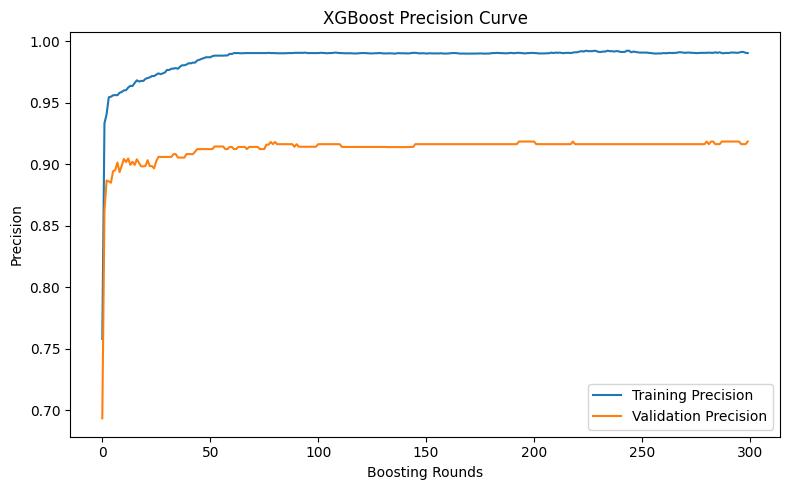

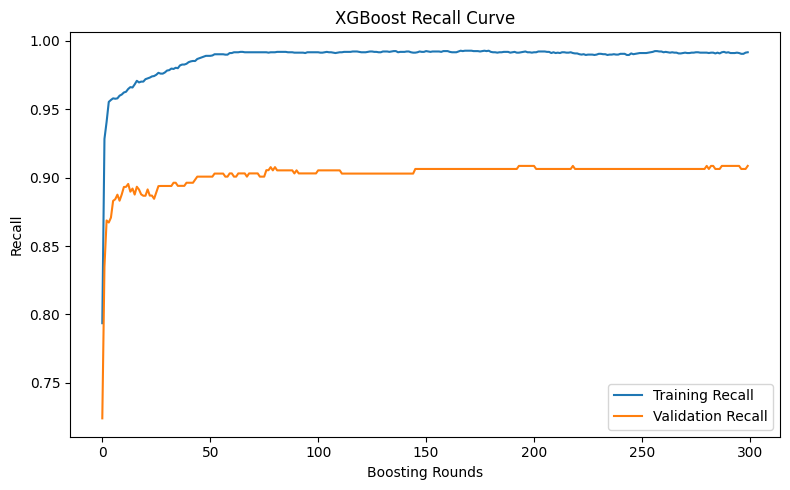

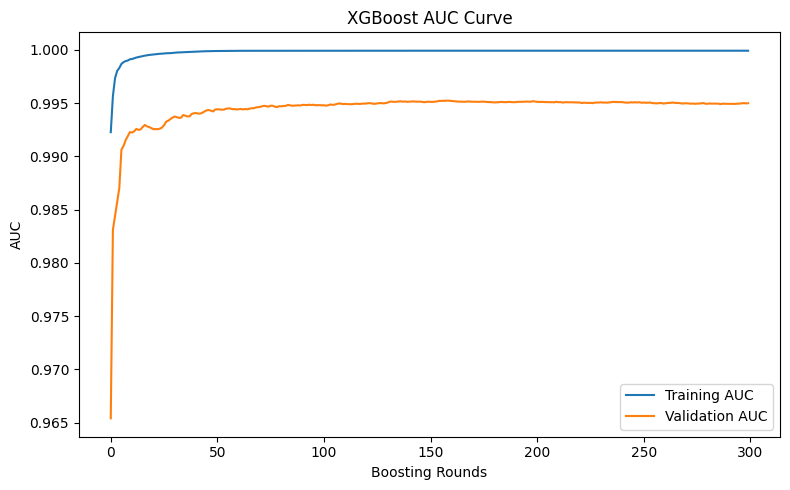

In [ ]:
# ============================================================
# Cell 13: Precision, Recall, AUC Curves
# ============================================================

from sklearn.metrics import precision_score, recall_score

train_precision = []
val_precision = []

train_recall = []
val_recall = []

train_auc = []
val_auc = []

classes = np.unique(y_train)

for i in range(1, 301):

    # Predict train
    train_pred = xgb_curve.predict(X_train_xgb, iteration_range=(0, i))
    train_prob = xgb_curve.predict_proba(X_train_xgb, iteration_range=(0, i))

    # Predict validation
    val_pred = xgb_curve.predict(X_val_xgb, iteration_range=(0, i))
    val_prob = xgb_curve.predict_proba(X_val_xgb, iteration_range=(0, i))

    # Precision
    train_precision.append(
        precision_score(y_train_xgb, train_pred, average='macro')
    )

    val_precision.append(
        precision_score(y_val_xgb, val_pred, average='macro')
    )

    # Recall
    train_recall.append(
        recall_score(y_train_xgb, train_pred, average='macro')
    )

    val_recall.append(
        recall_score(y_val_xgb, val_pred, average='macro')
    )

    # AUC
    y_train_bin = label_binarize(y_train_xgb, classes=classes)
    y_val_bin = label_binarize(y_val_xgb, classes=classes)

    train_auc.append(
        roc_auc_score(
            y_train_bin,
            train_prob,
            multi_class='ovr'
        )
    )

    val_auc.append(
        roc_auc_score(
            y_val_bin,
            val_prob,
            multi_class='ovr'
        )
    )

# ---------------- Precision Curve ----------------
plt.figure(figsize=(8,5))

plt.plot(train_precision, label='Training Precision')
plt.plot(val_precision, label='Validation Precision')

plt.xlabel("Boosting Rounds")
plt.ylabel("Precision")
plt.title("XGBoost Precision Curve")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgb_precision_curve.png", dpi=300)
plt.show()

# ---------------- Recall Curve ----------------
plt.figure(figsize=(8,5))

plt.plot(train_recall, label='Training Recall')
plt.plot(val_recall, label='Validation Recall')

plt.xlabel("Boosting Rounds")
plt.ylabel("Recall")
plt.title("XGBoost Recall Curve")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgb_recall_curve.png", dpi=300)
plt.show()

# ---------------- AUC Curve ----------------
plt.figure(figsize=(8,5))

plt.plot(train_auc, label='Training AUC')
plt.plot(val_auc, label='Validation AUC')

plt.xlabel("Boosting Rounds")
plt.ylabel("AUC")
plt.title("XGBoost AUC Curve")
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/xgb_auc_curve.png", dpi=300)
plt.show()


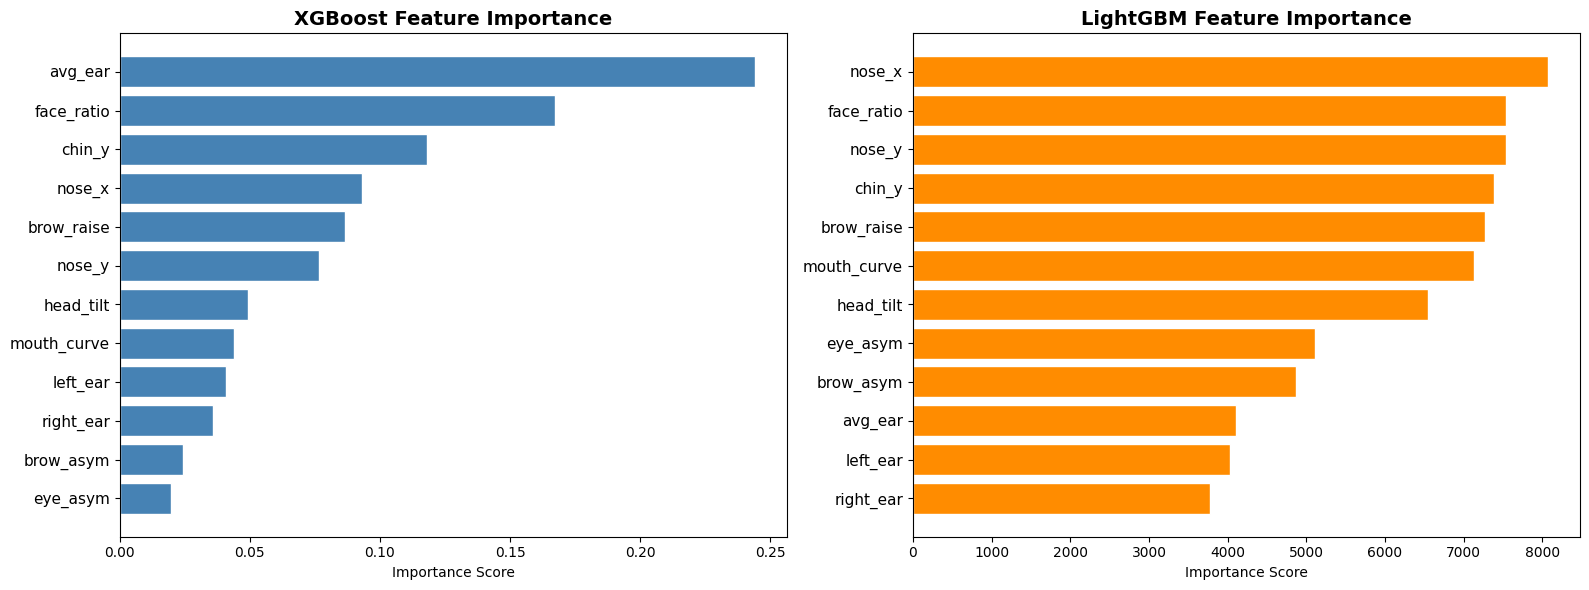

Feature importance saved.


In [ ]:
# ============================================================
# Feature Importance — XGBoost & LightGBM
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

FEAT_COLS = ['nose_x','nose_y','chin_y','avg_ear','head_tilt',
             'left_ear','right_ear','eye_asym',
             'brow_raise','brow_asym','mouth_curve','face_ratio']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- XGBoost ---
xgb_importance = xgb.feature_importances_
sorted_idx_xgb = np.argsort(xgb_importance)
axes[0].barh(np.array(FEAT_COLS)[sorted_idx_xgb], xgb_importance[sorted_idx_xgb],
             color='steelblue', edgecolor='white')
axes[0].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].tick_params(axis='y', labelsize=11)

# --- LightGBM ---
lgbm_importance = lgbm.feature_importances_
sorted_idx_lgbm = np.argsort(lgbm_importance)
axes[1].barh(np.array(FEAT_COLS)[sorted_idx_lgbm], lgbm_importance[sorted_idx_lgbm],
             color='darkorange', edgecolor='white')
axes[1].set_title('LightGBM Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150)
plt.show()
print("Feature importance saved.")

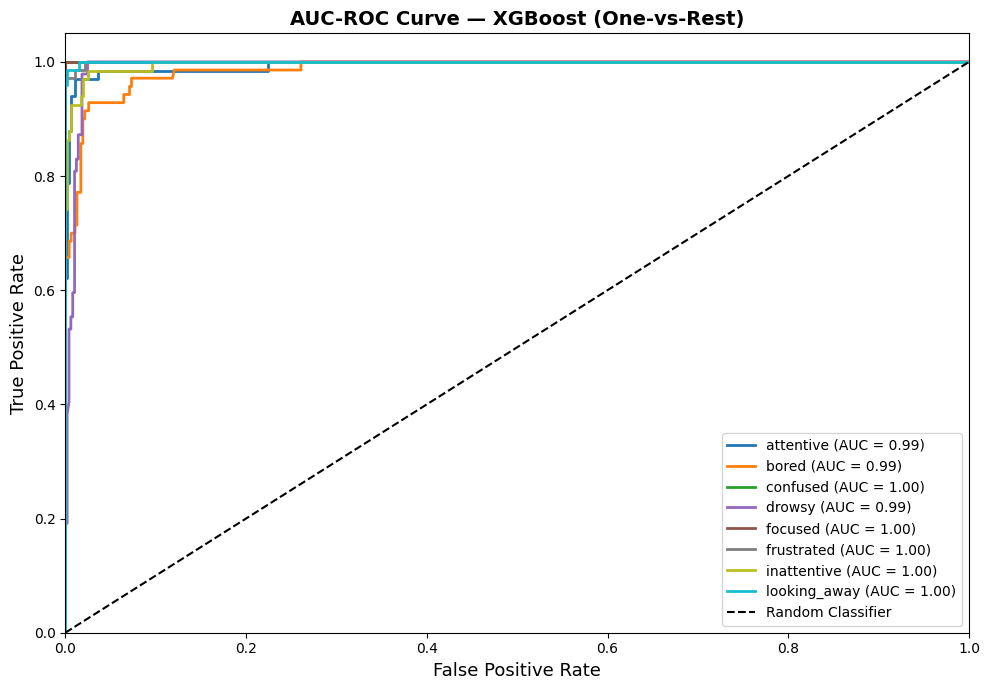

AUC-ROC curve saved.


In [ ]:
# ============================================================
# AUC-ROC Curve — XGBoost (One-vs-Rest, per class)
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_score_xgb = xgb.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('AUC-ROC Curve — XGBoost (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/auc_roc_curve.png', dpi=150)
plt.show()
print("AUC-ROC curve saved.")

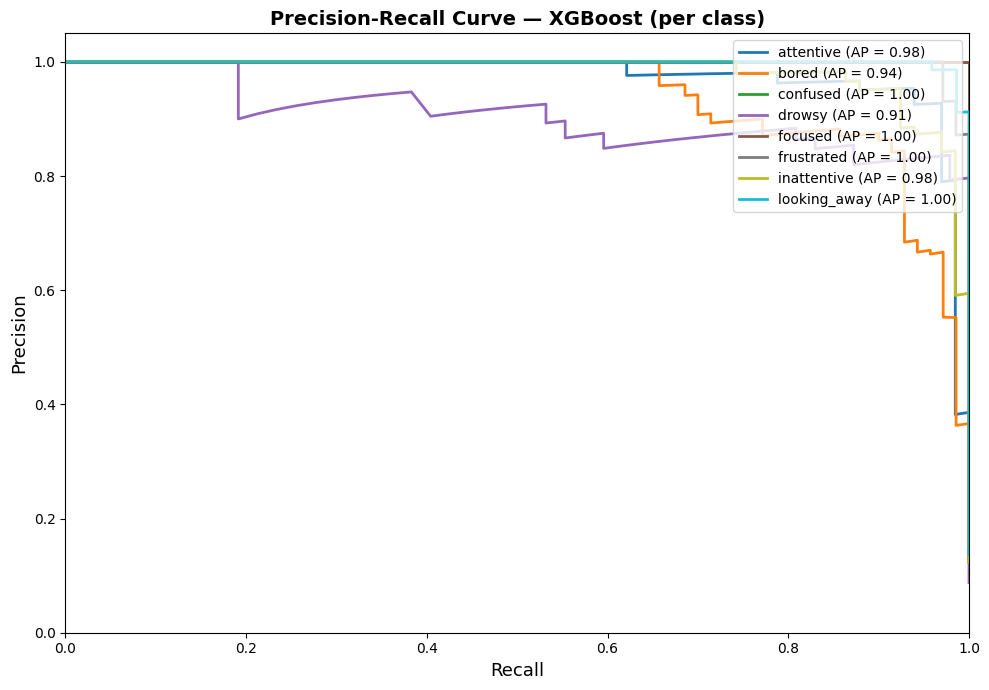

Precision-Recall curve saved.


In [ ]:
# ============================================================
# Precision-Recall Curve — XGBoost (per class)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_xgb[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_xgb[:, i])
    ax.plot(recall, precision, color=color, lw=2,
            label=f'{cls_name} (AP = {ap:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — XGBoost (per class)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/precision_recall_curve.png', dpi=150)
plt.show()
print("Precision-Recall curve saved.")

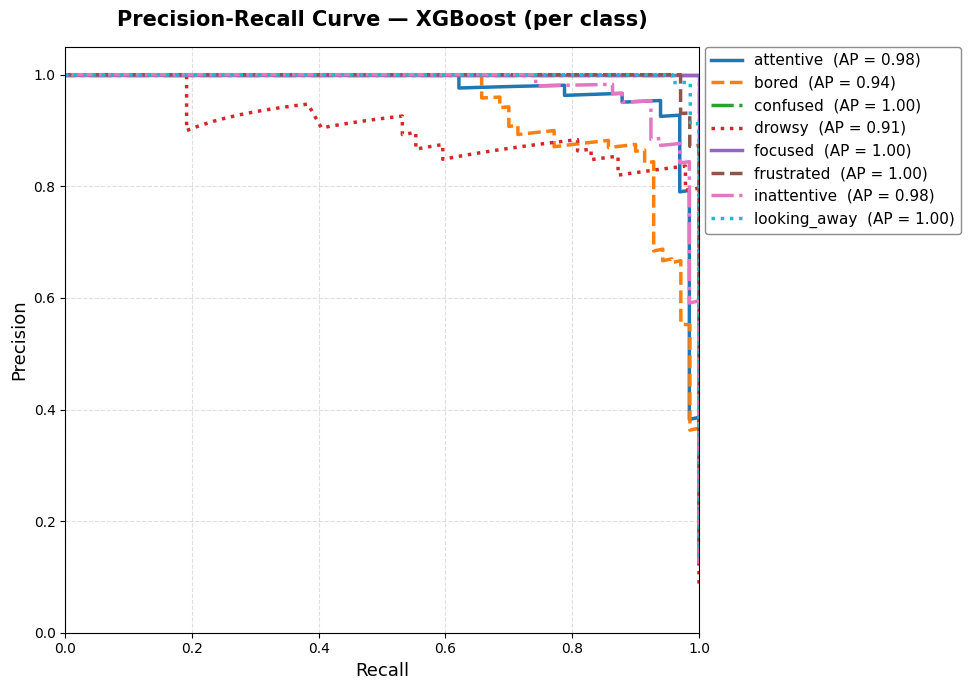

Fixed Precision-Recall curve saved.


In [ ]:
# ============================================================
# Precision-Recall Curve — XGBoost (per class) — FIXED
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_score_xgb = xgb.predict_proba(X_test)

# Distinct colors and line styles for 8 classes
colors     = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
              '#9467bd','#8c564b','#e377c2','#17becf']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
linewidths = [2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]

fig, ax = plt.subplots(figsize=(12, 7))

for i, cls_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_xgb[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_xgb[:, i])
    ax.plot(recall, precision,
            color=colors[i],
            linestyle=linestyles[i],
            linewidth=linewidths[i],
            label=f'{cls_name}  (AP = {ap:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — XGBoost (per class)', fontsize=15, fontweight='bold', pad=15)

ax.grid(True, linestyle='--', alpha=0.4)

# Legend placed OUTSIDE the plot on the right
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray'
)

plt.tight_layout(rect=[0, 0, 0.82, 1])   # leave room for the external legend
plt.savefig(f'{OUTPUT_DIR}/precision_recall_curve_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fixed Precision-Recall curve saved.")

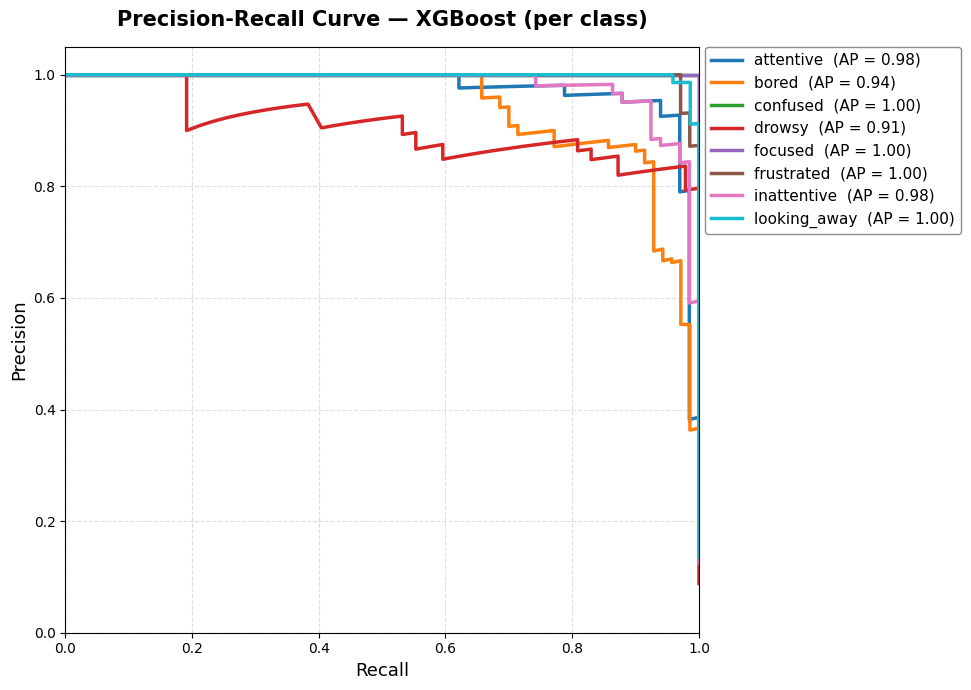

Solid line Precision-Recall curve saved.


In [ ]:
# ============================================================
# Precision-Recall Curve — XGBoost (per class) — SOLID LINES
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
y_score_xgb = xgb.predict_proba(X_test)

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#17becf']

fig, ax = plt.subplots(figsize=(12, 7))

for i, cls_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_xgb[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_xgb[:, i])
    ax.plot(recall, precision,
            color=colors[i],
            linestyle='-',        # solid for all
            linewidth=2.5,
            label=f'{cls_name}  (AP = {ap:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — XGBoost (per class)', fontsize=15, fontweight='bold', pad=15)

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray'
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(f'{OUTPUT_DIR}/precision_recall_curve_solid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Solid line Precision-Recall curve saved.")

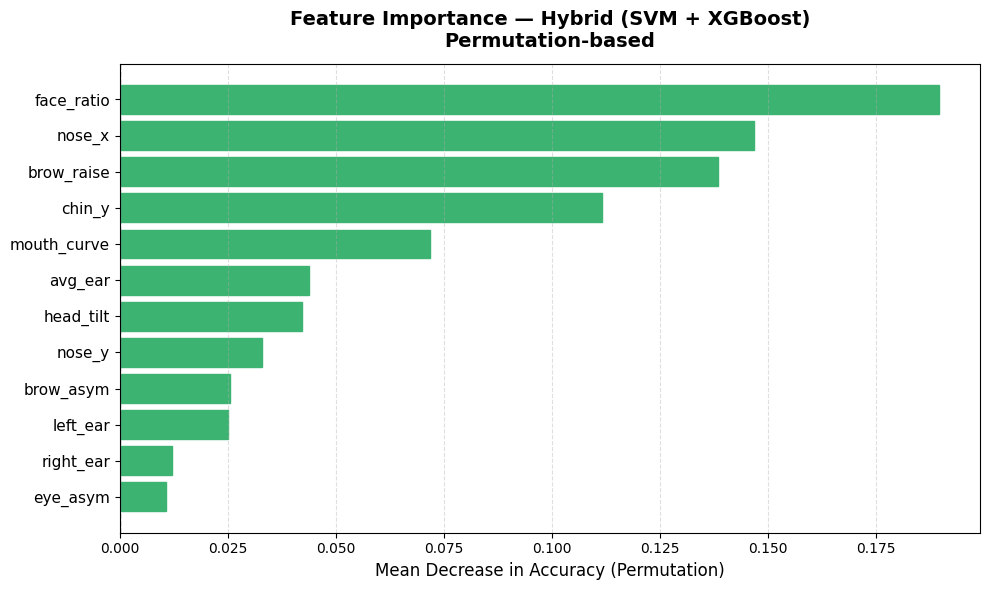

Hybrid feature importance saved.


In [ ]:
# ============================================================
# Feature Importance — Hybrid (SVM + XGBoost) via Permutation
# ============================================================
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Hybrid predict function wrapper
def hybrid_predict(X):
    prob_s = svm.predict_proba(scaler.transform(X))
    prob_x = xgb.predict_proba(X)
    return np.argmax((prob_s + prob_x) / 2, axis=1)

# Permutation importance on test set
from sklearn.metrics import accuracy_score

baseline_acc = accuracy_score(y_test, hybrid_predict(X_test))
n_repeats = 10
rng = np.random.RandomState(42)

importances = []
for col in range(X_test.shape[1]):
    scores = []
    for _ in range(n_repeats):
        X_permuted = X_test.copy()
        X_permuted[:, col] = rng.permutation(X_permuted[:, col])
        perm_acc = accuracy_score(y_test, hybrid_predict(X_permuted))
        scores.append(baseline_acc - perm_acc)   # drop in accuracy
    importances.append(np.mean(scores))

importances = np.array(importances)
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(np.array(FEAT_COLS)[sorted_idx], importances[sorted_idx],
               color='mediumseagreen', edgecolor='white')

# Highlight negative importances (features that don't help)
for bar, val in zip(bars, importances[sorted_idx]):
    bar.set_color('salmon' if val < 0 else 'mediumseagreen')

ax.axvline(x=0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Mean Decrease in Accuracy (Permutation)', fontsize=12)
ax.set_title('Feature Importance — Hybrid (SVM + XGBoost)\nPermutation-based',
             fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/hybrid_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hybrid feature importance saved.")

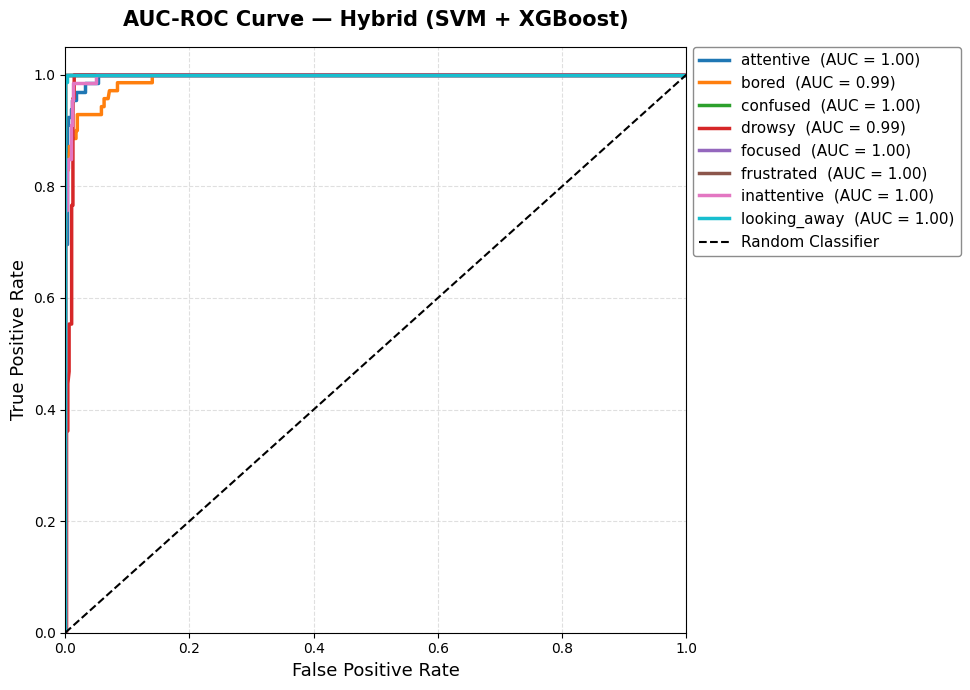

Hybrid AUC-ROC curve saved.


In [ ]:
# ============================================================
# AUC-ROC Curve — Hybrid (SVM + XGBoost)
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes   = len(le.classes_)
y_test_bin  = label_binarize(y_test, classes=np.arange(n_classes))

# Hybrid probabilities (already computed earlier)
prob_svm    = svm.predict_proba(X_test_scaled)
prob_xgb    = xgb.predict_proba(X_test)
hybrid_probs = (prob_svm + prob_xgb) / 2

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#17becf']

fig, ax = plt.subplots(figsize=(12, 7))

for i, cls_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], hybrid_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr,
            color=colors[i],
            linestyle='-',
            linewidth=2.5,
            label=f'{cls_name}  (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('AUC-ROC Curve — Hybrid (SVM + XGBoost)',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray'
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(f'{OUTPUT_DIR}/hybrid_auc_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hybrid AUC-ROC curve saved.")

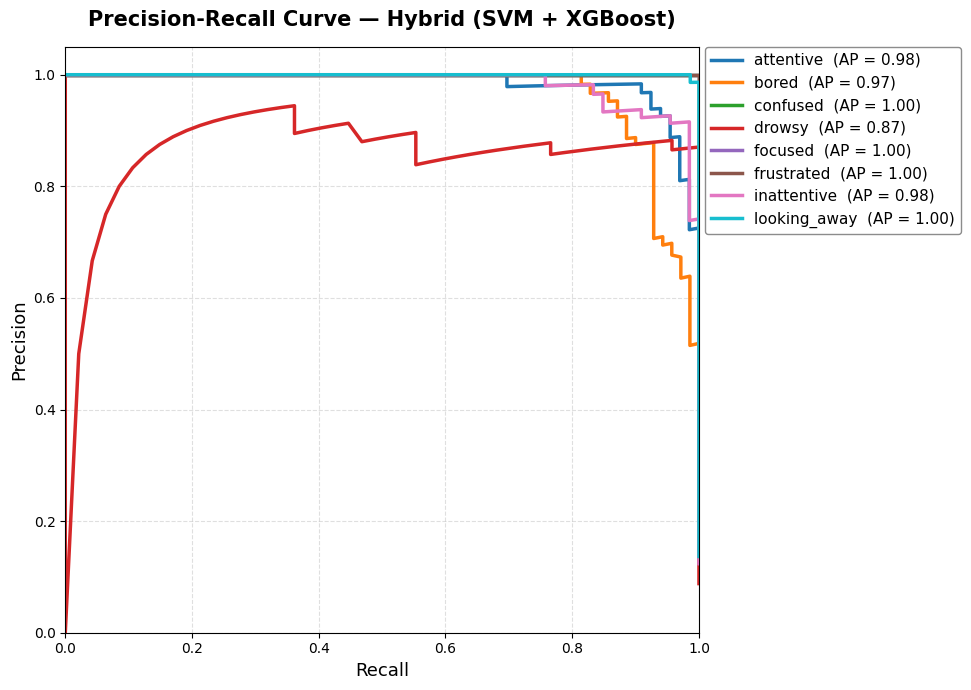

Hybrid Precision-Recall curve saved.


In [ ]:
# ============================================================
# Precision-Recall Curve — Hybrid (SVM + XGBoost)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#17becf']

fig, ax = plt.subplots(figsize=(12, 7))

for i, cls_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], hybrid_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], hybrid_probs[:, i])
    ax.plot(recall, precision,
            color=colors[i],
            linestyle='-',
            linewidth=2.5,
            label=f'{cls_name}  (AP = {ap:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Hybrid (SVM + XGBoost)',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray'
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(f'{OUTPUT_DIR}/hybrid_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hybrid Precision-Recall curve saved.")

Computing SVM permutation importance  (this may take ~1-2 min)...
Computing Hybrid permutation importance (this may take ~1-2 min)...


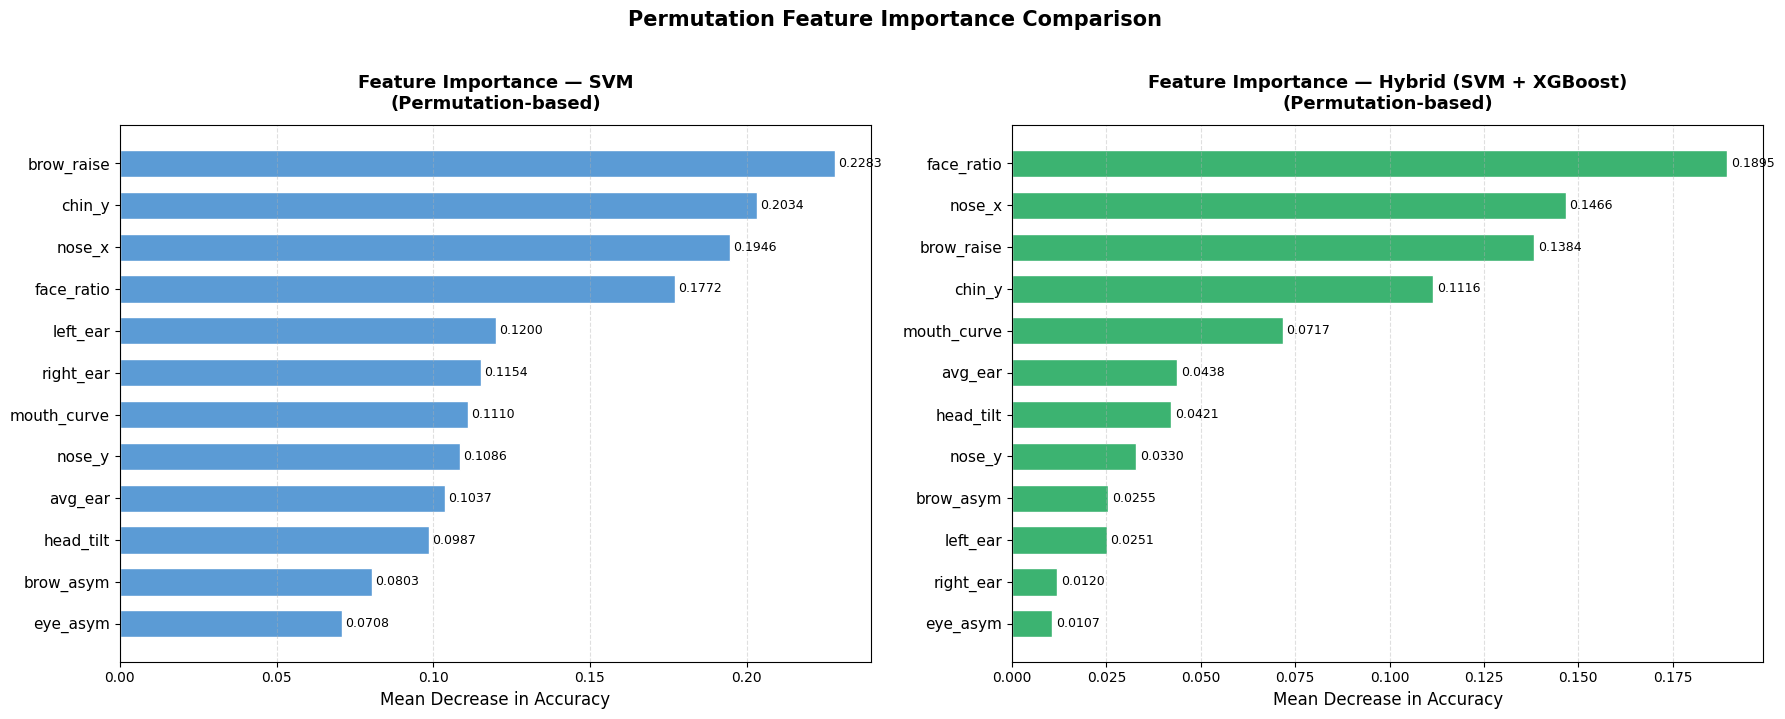

SVM & Hybrid feature importance saved.


In [ ]:
# ============================================================
# Feature Importance — SVM & Hybrid (SVM + XGBoost)
# Permutation-based, side by side
# ============================================================
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

n_repeats = 10
rng = np.random.RandomState(42)

# ── Helper: permutation importance for any predict function ──
def permutation_importance_custom(predict_fn, X, y_true, n_repeats=10, seed=42):
    rng = np.random.RandomState(seed)
    baseline = accuracy_score(y_true, predict_fn(X))
    importances = []
    for col in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, col] = rng.permutation(X_perm[:, col])
            scores.append(baseline - accuracy_score(y_true, predict_fn(X_perm)))
        importances.append(np.mean(scores))
    return np.array(importances)

# ── SVM predict (uses scaled input) ──
def svm_predict(X):
    return svm.predict(scaler.transform(X))

# ── Hybrid predict (soft voting) ──
def hybrid_predict(X):
    prob_s = svm.predict_proba(scaler.transform(X))
    prob_x = xgb.predict_proba(X)
    return np.argmax((prob_s + prob_x) / 2, axis=1)

print("Computing SVM permutation importance  (this may take ~1-2 min)...")
svm_imp = permutation_importance_custom(svm_predict, X_test, y_test)

print("Computing Hybrid permutation importance (this may take ~1-2 min)...")
hybrid_imp = permutation_importance_custom(hybrid_predict, X_test, y_test)

# ── Plot side by side ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def plot_importance(ax, importances, title, color_pos, color_neg):
    sorted_idx = np.argsort(importances)
    colors_bar = [color_neg if v < 0 else color_pos for v in importances[sorted_idx]]
    bars = ax.barh(
        np.array(FEAT_COLS)[sorted_idx],
        importances[sorted_idx],
        color=colors_bar,
        edgecolor='white',
        height=0.65
    )
    ax.axvline(x=0, color='gray', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Mean Decrease in Accuracy', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

    # Value labels on bars
    for bar, val in zip(bars, importances[sorted_idx]):
        offset = 0.001 if val >= 0 else -0.001
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha=ha, fontsize=9)

plot_importance(axes[0], svm_imp,
                'Feature Importance — SVM\n(Permutation-based)',
                color_pos='#5B9BD5', color_neg='salmon')

plot_importance(axes[1], hybrid_imp,
                'Feature Importance — Hybrid (SVM + XGBoost)\n(Permutation-based)',
                color_pos='mediumseagreen', color_neg='salmon')

plt.suptitle('Permutation Feature Importance Comparison',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/svm_hybrid_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SVM & Hybrid feature importance saved.")